In [1]:
import pandas as pd
from pathlib import Path

relative_path = Path(
    "data/processed/monthly_topic_lag_features.pkl"
)

project_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / relative_path).is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        f"Could not find {relative_path} from {Path.cwd()}"
    )

input_path = project_root / relative_path

lag_df = pd.read_pickle(input_path)

print("Loaded:", input_path)
print("Shape:", lag_df.shape)

display(lag_df.head())

Loaded: d:\data mining\e_waste_topic_modeling\data\processed\monthly_topic_lag_features.pkl
Shape: (81, 34)


,review_month,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,review_count,...,topic_4_prob_lag3,topic_5_prob_lag1,topic_5_prob_lag2,topic_5_prob_lag3,topic_6_prob_lag1,topic_6_prob_lag2,topic_6_prob_lag3,topic_7_prob_lag1,topic_7_prob_lag2,topic_7_prob_lag3
0,2012-01,0.093585,0.063902,0.175746,0.126663,0.218792,0.113825,0.110730,0.096756,216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-02,0.092701,0.082617,0.158101,0.135460,0.189534,0.127680,0.123208,0.090700,225,...,NaN,0.113825,NaN,NaN,0.110730,NaN,NaN,0.096756,NaN,NaN
2,2012-03,0.110264,0.074631,0.157414,0.137102,0.180182,0.096718,0.140700,0.102990,243,...,NaN,0.127680,0.113825,NaN,0.123208,0.110730,NaN,0.090700,0.096756,NaN
3,2012-04,0.106078,0.066215,0.166059,0.113816,0.229618,0.108666,0.115028,0.094519,233,...,0.218792,0.096718,0.127680,0.113825,0.140700,0.123208,0.110730,0.102990,0.090700,0.096756
4,2012-05,0.133956,0.070029,0.149698,0.144705,0.188220,0.096539,0.118867,0.097987,264,...,0.189534,0.108666,0.096718,0.127680,0.115028,0.140700,0.123208,0.094519,0.102990,0.090700


In [2]:
prediction_topics = [0, 1, 5]

model_df = lag_df.copy()

for topic_id in prediction_topics:
    current_col = f"topic_{topic_id}_prob"
    target_col = f"topic_{topic_id}_increase_next"

    model_df[target_col] = (
        model_df[current_col].shift(-1) > model_df[current_col]
    ).astype("Int64")

print("Prediction topics:", prediction_topics)

display(
    model_df[
        [
            "review_month",
            "topic_0_prob",
            "topic_0_increase_next",
            "topic_1_prob",
            "topic_1_increase_next",
            "topic_5_prob",
            "topic_5_increase_next",
        ]
    ].head(10)
)

Prediction topics: [0, 1, 5]


,review_month,topic_0_prob,topic_0_increase_next,topic_1_prob,topic_1_increase_next,topic_5_prob,topic_5_increase_next
0,2012-01,0.093585,0,0.063902,1,0.113825,1
1,2012-02,0.092701,1,0.082617,0,0.127680,0
2,2012-03,0.110264,0,0.074631,0,0.096718,1
3,2012-04,0.106078,1,0.066215,1,0.108666,0
4,2012-05,0.133956,0,0.070029,1,0.096539,1
5,2012-06,0.126379,0,0.076060,1,0.101321,0
6,2012-07,0.091966,0,0.085101,1,0.099146,1
7,2012-08,0.067933,1,0.086299,0,0.125148,0
8,2012-09,0.091751,1,0.077814,1,0.082970,0
9,2012-10,0.129901,0,0.079092,1,0.075226,1


In [3]:
for topic_id in prediction_topics:
    target_col = f"topic_{topic_id}_increase_next"

    print(f"\nTopic {topic_id}")
    print(
        model_df[target_col]
        .value_counts(dropna=True)
        .sort_index()
    )

    print(
        model_df[target_col]
        .value_counts(normalize=True, dropna=True)
        .sort_index()
    )


Topic 0
topic_0_increase_next
0    45
1    36
Name: count, dtype: Int64
topic_0_increase_next
0    0.555556
1    0.444444
Name: proportion, dtype: Float64

Topic 1
topic_1_increase_next
0    36
1    45
Name: count, dtype: Int64
topic_1_increase_next
0    0.444444
1    0.555556
Name: proportion, dtype: Float64

Topic 5
topic_5_increase_next
0    37
1    44
Name: count, dtype: Int64
topic_5_increase_next
0    0.45679
1    0.54321
Name: proportion, dtype: Float64


In [4]:
# Bỏ các dòng chưa đủ lag và dòng cuối không có tháng kế tiếp
model_data = model_df.dropna(
    subset=[
        "topic_0_prob_lag1",
        "topic_0_prob_lag2",
        "topic_0_prob_lag3",
        "topic_0_increase_next",
        "topic_1_increase_next",
        "topic_5_increase_next",
    ]
).copy()

# Feature columns: current prevalence + lag 1, 2, 3
feature_cols = []

for topic_id in prediction_topics:
    feature_cols.append(f"topic_{topic_id}_prob")
    feature_cols.extend([
        f"topic_{topic_id}_prob_lag1",
        f"topic_{topic_id}_prob_lag2",
        f"topic_{topic_id}_prob_lag3",
    ])

# Time-based split
train_data = model_data[
    model_data["review_month"] <= pd.Period("2017-12", freq="M")
].copy()

test_data = model_data[
    (
        model_data["review_month"] >= pd.Period("2018-01", freq="M")
    )
    &
    (
        model_data["review_month"] <= pd.Period("2018-09", freq="M")
    )
].copy()

print("Feature count:", len(feature_cols))
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("Train period:", train_data["review_month"].min(), "→", train_data["review_month"].max())
print("Test period:", test_data["review_month"].min(), "→", test_data["review_month"].max())

Feature count: 12
Train shape: (69, 37)
Test shape: (9, 37)
Train period: 2012-04 → 2017-12
Test period: 2018-01 → 2018-09


In [5]:
X_train = train_data[feature_cols].copy()
X_test = test_data[feature_cols].copy()

y_train = {}
y_test = {}

for topic_id in prediction_topics:
    target_col = f"topic_{topic_id}_increase_next"

    y_train[topic_id] = train_data[target_col].astype(int)
    y_test[topic_id] = test_data[target_col].astype(int)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

for topic_id in prediction_topics:
    print(
        f"Topic {topic_id}: "
        f"y_train={y_train[topic_id].shape}, "
        f"y_test={y_test[topic_id].shape}"
    )

X_train shape: (69, 12)
X_test shape: (9, 12)
Topic 0: y_train=(69,), y_test=(9,)
Topic 1: y_train=(69,), y_test=(9,)
Topic 5: y_train=(69,), y_test=(9,)


In [6]:
from sklearn.tree import DecisionTreeClassifier

models = {}
predictions = {}

for topic_id in prediction_topics:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=3,
        random_state=42
    )

    model.fit(
        X_train,
        y_train[topic_id]
    )

    models[topic_id] = model
    predictions[topic_id] = model.predict(X_test)

    print(
        f"Topic {topic_id}: "
        f"training accuracy = {model.score(X_train, y_train[topic_id]):.4f}"
    )

Topic 0: training accuracy = 0.8261
Topic 1: training accuracy = 0.7681
Topic 5: training accuracy = 0.7101


In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

results = []

for topic_id in prediction_topics:
    y_true = y_test[topic_id]
    y_pred = predictions[topic_id]

    results.append({
        "topic": topic_id,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    })

    print(f"\nTopic {topic_id}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

results_df = pd.DataFrame(results)

display(results_df)


Topic 0
Confusion Matrix:
[[4 2]
 [2 1]]

Topic 1
Confusion Matrix:
[[5 0]
 [4 0]]

Topic 5
Confusion Matrix:
[[3 1]
 [4 1]]


,topic,accuracy,precision,recall,f1
0,0,0.555556,0.333333,0.333333,0.333333
1,1,0.555556,0.000000,0.000000,0.000000
2,5,0.444444,0.500000,0.200000,0.285714


In [8]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tscv = TimeSeriesSplit(n_splits=5)

depth_results = []

for topic_id in prediction_topics:
    for depth in [1, 2, 3, 4, 5]:
        scores = []

        for train_idx, val_idx in tscv.split(X_train):
            X_tr = X_train.iloc[train_idx]
            X_val = X_train.iloc[val_idx]

            y_tr = y_train[topic_id].iloc[train_idx]
            y_val = y_train[topic_id].iloc[val_idx]

            model = DecisionTreeClassifier(
                criterion="entropy",
                max_depth=depth,
                random_state=42
            )

            model.fit(X_tr, y_tr)
            pred = model.predict(X_val)

            scores.append(
                accuracy_score(y_val, pred)
            )

        depth_results.append({
            "topic": topic_id,
            "max_depth": depth,
            "cv_accuracy_mean": sum(scores) / len(scores)
        })

depth_results_df = pd.DataFrame(depth_results)

display(
    depth_results_df.sort_values(
        ["topic", "cv_accuracy_mean"],
        ascending=[True, False]
    )
)

,topic,max_depth,cv_accuracy_mean
4,0,5,0.654545
1,0,2,0.636364
0,0,1,0.618182
2,0,3,0.600000
3,0,4,0.600000
9,1,5,0.636364
7,1,3,0.600000
8,1,4,0.600000
6,1,2,0.563636
5,1,1,0.509091


In [9]:
best_depths = {
    0: 5,
    1: 5,
    5: 3
}

final_models = {}
final_predictions = {}

for topic_id in prediction_topics:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=best_depths[topic_id],
        random_state=42
    )

    model.fit(
        X_train,
        y_train[topic_id]
    )

    final_models[topic_id] = model
    final_predictions[topic_id] = model.predict(X_test)

    print(
        f"Topic {topic_id}: "
        f"depth={best_depths[topic_id]}, "
        f"training accuracy={model.score(X_train, y_train[topic_id]):.4f}"
    )

Topic 0: depth=5, training accuracy=0.9855
Topic 1: depth=5, training accuracy=0.9130
Topic 5: depth=3, training accuracy=0.7101


In [10]:
final_results = []

for topic_id in prediction_topics:
    y_true = y_test[topic_id]
    y_pred = final_predictions[topic_id]

    final_results.append({
        "topic": topic_id,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_true, y_pred, zero_division=0
        )
    })

    print(f"\nTopic {topic_id}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

final_results_df = pd.DataFrame(final_results)

display(final_results_df)


Topic 0
Confusion Matrix:
[[1 5]
 [1 2]]

Topic 1
Confusion Matrix:
[[5 0]
 [3 1]]

Topic 5
Confusion Matrix:
[[3 1]
 [4 1]]


,topic,accuracy,precision,recall,f1
0,0,0.333333,0.285714,0.666667,0.400000
1,1,0.666667,1.000000,0.250000,0.400000
2,5,0.444444,0.500000,0.200000,0.285714


In [11]:
from sklearn.naive_bayes import GaussianNB

nb_models = {}
nb_predictions = {}

for topic_id in prediction_topics:
    model = GaussianNB()

    model.fit(
        X_train,
        y_train[topic_id]
    )

    nb_models[topic_id] = model
    nb_predictions[topic_id] = model.predict(X_test)

    print(
        f"Topic {topic_id}: "
        f"training accuracy={model.score(X_train, y_train[topic_id]):.4f}"
    )

Topic 0: training accuracy=0.6522
Topic 1: training accuracy=0.5797
Topic 5: training accuracy=0.5652


In [12]:
nb_results = []

for topic_id in prediction_topics:
    y_true = y_test[topic_id]
    y_pred = nb_predictions[topic_id]

    nb_results.append({
        "topic": topic_id,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_true, y_pred, zero_division=0
        )
    })

    print(f"\nTopic {topic_id}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

nb_results_df = pd.DataFrame(nb_results)

display(nb_results_df)


Topic 0
Confusion Matrix:
[[3 3]
 [2 1]]

Topic 1
Confusion Matrix:
[[0 5]
 [0 4]]

Topic 5
Confusion Matrix:
[[4 0]
 [5 0]]


,topic,accuracy,precision,recall,f1
0,0,0.444444,0.250000,0.333333,0.285714
1,1,0.444444,0.444444,1.000000,0.615385
2,5,0.444444,0.000000,0.000000,0.000000


In [13]:
import pandas as pd
from pathlib import Path

relative_path = Path("data/processed/monthly_topic_lag_features.pkl")

project_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / relative_path).is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        f"Không tìm thấy file: {relative_path}"
    )

lag_path = project_root / relative_path

lag_df = pd.read_pickle(lag_path)

print("Project root:", project_root)
print("Shape:", lag_df.shape)
print("\nColumns:")
print(lag_df.columns.tolist())
print("\nHead:")
display(lag_df.head())

Project root: d:\data mining\e_waste_topic_modeling
Shape: (81, 34)

Columns:
['review_month', 'topic_0_prob', 'topic_1_prob', 'topic_2_prob', 'topic_3_prob', 'topic_4_prob', 'topic_5_prob', 'topic_6_prob', 'topic_7_prob', 'review_count', 'topic_0_prob_lag1', 'topic_0_prob_lag2', 'topic_0_prob_lag3', 'topic_1_prob_lag1', 'topic_1_prob_lag2', 'topic_1_prob_lag3', 'topic_2_prob_lag1', 'topic_2_prob_lag2', 'topic_2_prob_lag3', 'topic_3_prob_lag1', 'topic_3_prob_lag2', 'topic_3_prob_lag3', 'topic_4_prob_lag1', 'topic_4_prob_lag2', 'topic_4_prob_lag3', 'topic_5_prob_lag1', 'topic_5_prob_lag2', 'topic_5_prob_lag3', 'topic_6_prob_lag1', 'topic_6_prob_lag2', 'topic_6_prob_lag3', 'topic_7_prob_lag1', 'topic_7_prob_lag2', 'topic_7_prob_lag3']

Head:


,review_month,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,review_count,...,topic_4_prob_lag3,topic_5_prob_lag1,topic_5_prob_lag2,topic_5_prob_lag3,topic_6_prob_lag1,topic_6_prob_lag2,topic_6_prob_lag3,topic_7_prob_lag1,topic_7_prob_lag2,topic_7_prob_lag3
0,2012-01,0.093585,0.063902,0.175746,0.126663,0.218792,0.113825,0.110730,0.096756,216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-02,0.092701,0.082617,0.158101,0.135460,0.189534,0.127680,0.123208,0.090700,225,...,NaN,0.113825,NaN,NaN,0.110730,NaN,NaN,0.096756,NaN,NaN
2,2012-03,0.110264,0.074631,0.157414,0.137102,0.180182,0.096718,0.140700,0.102990,243,...,NaN,0.127680,0.113825,NaN,0.123208,0.110730,NaN,0.090700,0.096756,NaN
3,2012-04,0.106078,0.066215,0.166059,0.113816,0.229618,0.108666,0.115028,0.094519,233,...,0.218792,0.096718,0.127680,0.113825,0.140700,0.123208,0.110730,0.102990,0.090700,0.096756
4,2012-05,0.133956,0.070029,0.149698,0.144705,0.188220,0.096539,0.118867,0.097987,264,...,0.189534,0.108666,0.096718,0.127680,0.115028,0.140700,0.123208,0.094519,0.102990,0.090700


In [ ]:
#Create continuous next-month targets

forecast_topics = [0, 1, 5]

for topic_id in forecast_topics:
    current_col = f"topic_{topic_id}_prob"
    target_col = f"topic_{topic_id}_next"

    lag_df[target_col] = lag_df[current_col].shift(-1)

print("Target columns created:")
print([f"topic_{topic_id}_next" for topic_id in forecast_topics])

display(
    lag_df[
        [
            "review_month",
            "topic_0_prob",
            "topic_0_next",
            "topic_1_prob",
            "topic_1_next",
            "topic_5_prob",
            "topic_5_next",
        ]
    ].head(10)
)

Target columns created:
['topic_0_next', 'topic_1_next', 'topic_5_next']


,review_month,topic_0_prob,topic_0_next,topic_1_prob,topic_1_next,topic_5_prob,topic_5_next
0,2012-01,0.093585,0.092701,0.063902,0.082617,0.113825,0.127680
1,2012-02,0.092701,0.110264,0.082617,0.074631,0.127680,0.096718
2,2012-03,0.110264,0.106078,0.074631,0.066215,0.096718,0.108666
3,2012-04,0.106078,0.133956,0.066215,0.070029,0.108666,0.096539
4,2012-05,0.133956,0.126379,0.070029,0.076060,0.096539,0.101321
5,2012-06,0.126379,0.091966,0.076060,0.085101,0.101321,0.099146
6,2012-07,0.091966,0.067933,0.085101,0.086299,0.099146,0.125148
7,2012-08,0.067933,0.091751,0.086299,0.077814,0.125148,0.082970
8,2012-09,0.091751,0.129901,0.077814,0.079092,0.082970,0.075226
9,2012-10,0.129901,0.088602,0.079092,0.081196,0.075226,0.091113


In [16]:
#Build chronological train/test data

model_topics = [0, 1, 5]

feature_cols = {}

for topic_id in model_topics:
    feature_cols[topic_id] = [
        f"topic_{topic_id}_prob",
        f"topic_{topic_id}_prob_lag1",
        f"topic_{topic_id}_prob_lag2",
        f"topic_{topic_id}_prob_lag3",
    ]

all_features = [
    col
    for cols in feature_cols.values()
    for col in cols
]

all_targets = [
    f"topic_{topic_id}_next"
    for topic_id in model_topics
]

model_df = lag_df.dropna(
    subset=all_features + all_targets
).copy()

train_data = model_df[
    model_df["review_month"] <= "2017-11"
].copy()

test_data = model_df[
    (model_df["review_month"] >= "2017-12") &
    (model_df["review_month"] <= "2018-08")
].copy()

print("Model data:", model_df.shape)
print("Train:", train_data.shape)
print("Test :", test_data.shape)

print("\nTrain period:")
print(train_data["review_month"].iloc[0], "→", train_data["review_month"].iloc[-1])

print("\nTest forecast origins:")
print(test_data["review_month"].iloc[0], "→", test_data["review_month"].iloc[-1])

print("\nExpected target period:")
print("2018-01 → 2018-09")

Model data: (77, 37)
Train: (68, 37)
Test : (9, 37)

Train period:
2012-04 → 2017-11

Test forecast origins:
2017-12 → 2018-08

Expected target period:
2018-01 → 2018-09


In [17]:
# Persistence baseline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_results = []

for topic_id in model_topics:
    current_col = f"topic_{topic_id}_prob"
    target_col = f"topic_{topic_id}_next"

    y_true = test_data[target_col]
    y_pred = test_data[current_col]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    baseline_results.append({
        "topic": f"T{topic_id}",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

baseline_results_df = pd.DataFrame(baseline_results)

display(baseline_results_df)

,topic,MAE,RMSE,R2
0,T0,0.011555,0.014629,-0.245220
1,T1,0.008036,0.010191,-0.870109
2,T5,0.008709,0.010032,0.148197


In [18]:
# Linear Regression forecasting

from sklearn.linear_model import LinearRegression

linear_models = {}
linear_results = []
linear_predictions = {}

for topic_id in model_topics:
    X_cols = feature_cols[topic_id]
    target_col = f"topic_{topic_id}_next"

    X_train = train_data[X_cols]
    y_train = train_data[target_col]

    X_test = test_data[X_cols]
    y_test = test_data[target_col]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    linear_models[topic_id] = model
    linear_predictions[topic_id] = y_pred

    linear_results.append({
        "topic": f"T{topic_id}",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

linear_results_df = pd.DataFrame(linear_results)

display(linear_results_df)

,topic,MAE,RMSE,R2
0,T0,0.011513,0.014228,-0.177998
1,T1,0.006659,0.008464,-0.289960
2,T5,0.008509,0.010338,0.095517


In [19]:
# Compare baseline and Linear Regression

comparison_df = baseline_results_df.merge(
    linear_results_df,
    on="topic",
    suffixes=("_baseline", "_linear")
)

comparison_df["MAE_improvement"] = (
    comparison_df["MAE_baseline"] -
    comparison_df["MAE_linear"]
)

comparison_df["RMSE_improvement"] = (
    comparison_df["RMSE_baseline"] -
    comparison_df["RMSE_linear"]
)

display(comparison_df)

,topic,MAE_baseline,RMSE_baseline,R2_baseline,MAE_linear,RMSE_linear,R2_linear,MAE_improvement,RMSE_improvement
0,T0,0.011555,0.014629,-0.245220,0.011513,0.014228,-0.177998,0.000041,0.000400
1,T1,0.008036,0.010191,-0.870109,0.006659,0.008464,-0.289960,0.001377,0.001727
2,T5,0.008709,0.010032,0.148197,0.008509,0.010338,0.095517,0.000200,-0.000306


In [20]:
# Ridge Regression forecasting

from sklearn.linear_model import Ridge

ridge_models = {}
ridge_results = []
ridge_predictions = {}

for topic_id in model_topics:
    X_cols = feature_cols[topic_id]
    target_col = f"topic_{topic_id}_next"

    X_train = train_data[X_cols]
    y_train = train_data[target_col]

    X_test = test_data[X_cols]
    y_test = test_data[target_col]

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    ridge_models[topic_id] = model
    ridge_predictions[topic_id] = y_pred

    ridge_results.append({
        "topic": f"T{topic_id}",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

ridge_results_df = pd.DataFrame(ridge_results)

display(ridge_results_df)

,topic,MAE,RMSE,R2
0,T0,0.020956,0.024392,-2.462185
1,T1,0.035456,0.036241,-22.648003
2,T5,0.030967,0.032810,-8.110817


In [21]:
# Final comparison of forecasting models

ridge_results_df = ridge_results_df.rename(
    columns={
        "MAE": "MAE_ridge",
        "RMSE": "RMSE_ridge",
        "R2": "R2_ridge"
    }
)

final_comparison = (
    baseline_results_df.rename(
        columns={
            "MAE": "MAE_baseline",
            "RMSE": "RMSE_baseline",
            "R2": "R2_baseline"
        }
    )
    .merge(
        linear_results_df.rename(
            columns={
                "MAE": "MAE_linear",
                "RMSE": "RMSE_linear",
                "R2": "R2_linear"
            }
        ),
        on="topic"
    )
    .merge(
        ridge_results_df,
        on="topic"
    )
)

display(final_comparison)

,topic,MAE_baseline,RMSE_baseline,R2_baseline,MAE_linear,RMSE_linear,R2_linear,MAE_ridge,RMSE_ridge,R2_ridge
0,T0,0.011555,0.014629,-0.245220,0.011513,0.014228,-0.177998,0.020956,0.024392,-2.462185
1,T1,0.008036,0.010191,-0.870109,0.006659,0.008464,-0.289960,0.035456,0.036241,-22.648003
2,T5,0.008709,0.010032,0.148197,0.008509,0.010338,0.095517,0.030967,0.032810,-8.110817


In [22]:
# Select final forecasting model

final_models = {}

for topic_id in model_topics:
    topic = f"T{topic_id}"

    row = final_comparison[
        final_comparison["topic"] == topic
    ].iloc[0]

    model_scores = {
        "Baseline": row["RMSE_baseline"],
        "Linear Regression": row["RMSE_linear"],
        "Ridge Regression": row["RMSE_ridge"]
    }

    best_model = min(
        model_scores,
        key=model_scores.get
    )

    final_models[topic_id] = best_model

    print(
        f"T{topic_id}: {best_model} "
        f"(RMSE = {model_scores[best_model]:.6f})"
    )

T0: Linear Regression (RMSE = 0.014228)
T1: Linear Regression (RMSE = 0.008464)
T5: Baseline (RMSE = 0.010032)


In [23]:
#Generate final predictions for 2018

final_predictions = []

for topic_id in model_topics:
    topic = f"T{topic_id}"
    target_col = f"topic_{topic_id}_next"

    X_cols = feature_cols[topic_id]

    if final_models[topic_id] == "Linear Regression":
        model = linear_models[topic_id]
        y_pred = model.predict(test_data[X_cols])
        
    else:
        # Persistence baseline
        y_pred = test_data[f"topic_{topic_id}_prob"].values

    for i in range(len(test_data)):
        final_predictions.append({
            "origin_month": test_data["review_month"].iloc[i],
            "target_month": (
                pd.Period(
                    test_data["review_month"].iloc[i],
                    freq="M"
                ) + 1
            ).strftime("%Y-%m"),
            "topic": topic,
            "actual": test_data[target_col].iloc[i],
            "predicted": y_pred[i],
            "model": final_models[topic_id]
        })

predictions_df = pd.DataFrame(final_predictions)

display(predictions_df)

,origin_month,target_month,topic,actual,predicted,model
0,2017-12,2018-01,T0,0.106799,0.108898,Linear Regression
1,2018-01,2018-02,T0,0.108401,0.109464,Linear Regression
2,2018-02,2018-03,T0,0.098819,0.109105,Linear Regression
3,2018-03,2018-04,T0,0.090853,0.102174,Linear Regression
4,2018-04,2018-05,T0,0.104361,0.096838,Linear Regression
5,2018-05,2018-06,T0,0.078495,0.105330,Linear Regression
6,2018-06,2018-07,T0,0.076135,0.085669,Linear Regression
7,2018-07,2018-08,T0,0.095098,0.084826,Linear Regression
8,2018-08,2018-09,T0,0.071625,0.096310,Linear Regression
9,2017-12,2018-01,T1,0.157062,0.159892,Linear Regression


In [24]:
# Save final forecasting results

output_path = project_root / "data/processed/topic_forecasts.pkl"

predictions_df.to_pickle(output_path)

print("Saved:", output_path)
print("Shape:", predictions_df.shape)
print("\nTopics:")
print(predictions_df["topic"].value_counts().sort_index())
print("\nTarget period:")
print(
    predictions_df["target_month"].min(),
    "→",
    predictions_df["target_month"].max()
)

Saved: d:\data mining\e_waste_topic_modeling\data\processed\topic_forecasts.pkl
Shape: (27, 6)

Topics:
topic
T0    9
T1    9
T5    9
Name: count, dtype: int64

Target period:
2018-01 → 2018-09


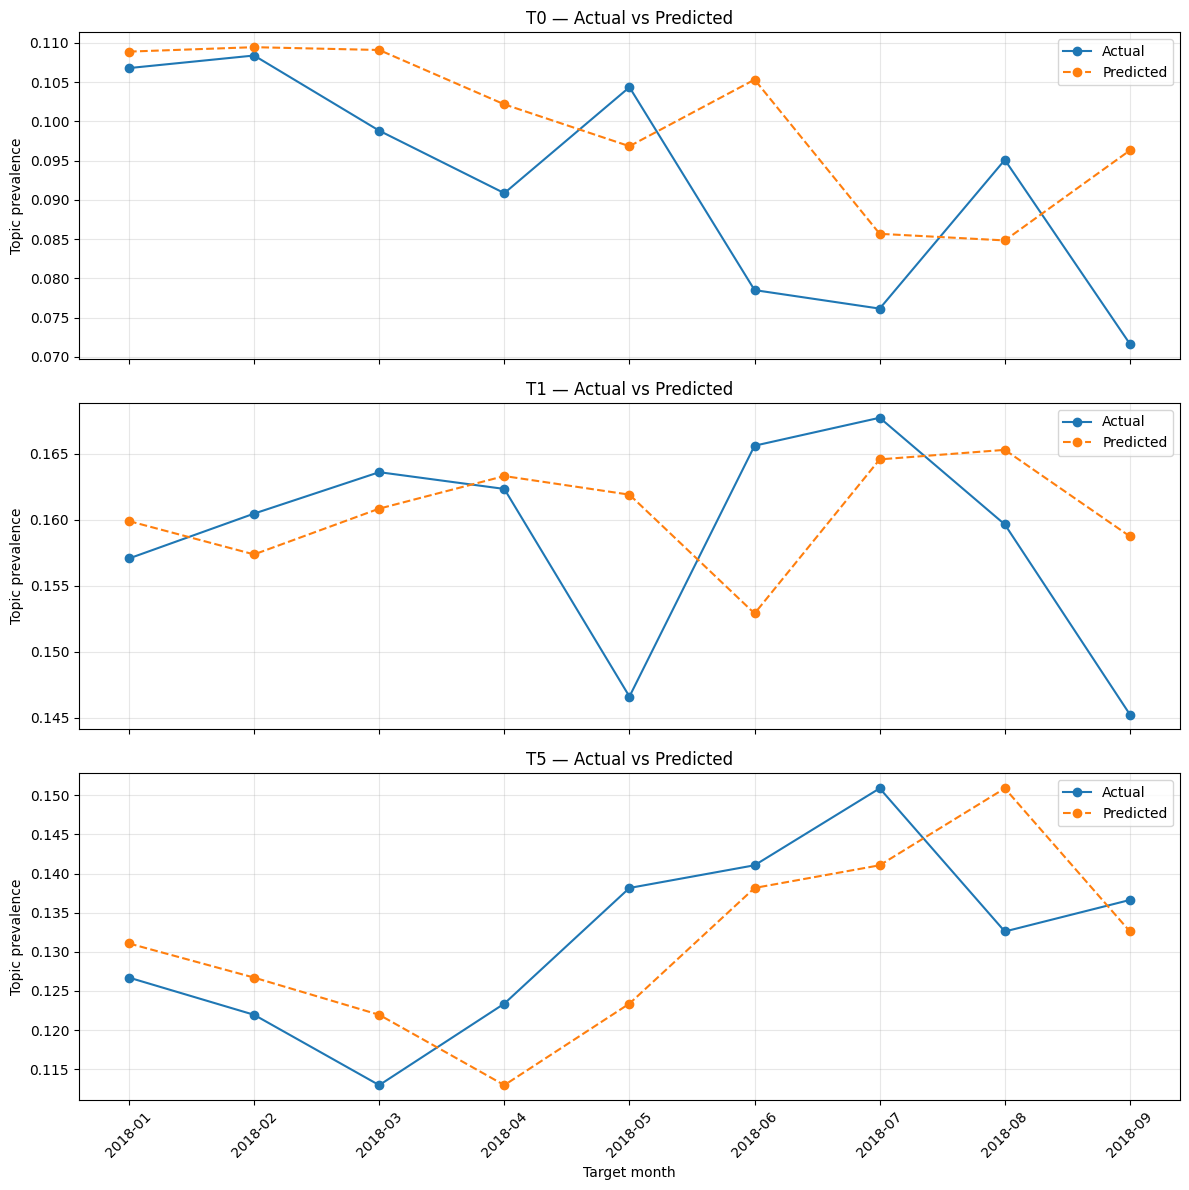

In [25]:
# Actual vs Predicted

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 12),
    sharex=True
)

for ax, topic in zip(axes, ["T0", "T1", "T5"]):
    plot_df = predictions_df[
        predictions_df["topic"] == topic
    ].copy()

    ax.plot(
        plot_df["target_month"],
        plot_df["actual"],
        marker="o",
        label="Actual"
    )

    ax.plot(
        plot_df["target_month"],
        plot_df["predicted"],
        marker="o",
        linestyle="--",
        label="Predicted"
    )

    ax.set_title(f"{topic} — Actual vs Predicted")
    ax.set_ylabel("Topic prevalence")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Target month")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# Monthly forecast errors

error_df = predictions_df.copy()

error_df["error"] = (
    error_df["predicted"] -
    error_df["actual"]
)

error_df["absolute_error"] = error_df["error"].abs()

display(
    error_df[
        [
            "target_month",
            "topic",
            "actual",
            "predicted",
            "error",
            "absolute_error",
            "model"
        ]
    ].sort_values(
        ["topic", "target_month"]
    )
)

,target_month,topic,actual,predicted,error,absolute_error,model
0,2018-01,T0,0.106799,0.108898,0.002099,0.002099,Linear Regression
1,2018-02,T0,0.108401,0.109464,0.001063,0.001063,Linear Regression
2,2018-03,T0,0.098819,0.109105,0.010286,0.010286,Linear Regression
3,2018-04,T0,0.090853,0.102174,0.011321,0.011321,Linear Regression
4,2018-05,T0,0.104361,0.096838,-0.007523,0.007523,Linear Regression
5,2018-06,T0,0.078495,0.105330,0.026835,0.026835,Linear Regression
6,2018-07,T0,0.076135,0.085669,0.009534,0.009534,Linear Regression
7,2018-08,T0,0.095098,0.084826,-0.010272,0.010272,Linear Regression
8,2018-09,T0,0.071625,0.096310,0.024685,0.024685,Linear Regression
9,2018-01,T1,0.157062,0.159892,0.002830,0.002830,Linear Regression


In [27]:
# Final forecasting error summary

forecast_summary = (
    error_df
    .groupby(["topic", "model"])
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("error", lambda x: np.sqrt(np.mean(x ** 2))),
        Mean_Error=("error", "mean"),
        Max_Absolute_Error=("absolute_error", "max")
    )
    .reset_index()
)

display(forecast_summary)

,topic,model,MAE,RMSE,Mean_Error,Max_Absolute_Error
0,T0,Linear Regression,0.011513,0.014228,0.007559,0.026835
1,T1,Linear Regression,0.006659,0.008464,0.001836,0.015284
2,T5,Baseline,0.008709,0.010032,-0.000618,0.018298


In [28]:
# Save final forecasting summary

summary_path = project_root / "data/processed/forecast_summary.pkl"

forecast_summary.to_pickle(summary_path)

print("Saved:", summary_path)
print("Shape:", forecast_summary.shape)

Saved: d:\data mining\e_waste_topic_modeling\data\processed\forecast_summary.pkl
Shape: (3, 6)
